# NLP Notebook
## Module 2: Text Preprocessing and Linguistic Fundamentals
## Module 3: Text Representation and Feature Engineering

**Author:** Mutua  
**Date:** Feb 2026

This notebook demonstrates a complete NLP pipeline:
- Text preprocessing
- Feature engineering
- Word embeddings
- Visualization


## 1. Import Required Libraries
We import NLP, machine learning, and visualization libraries.

In [1]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import gutenberg

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA

from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('gutenberg')

[nltk_data] Downloading package punkt to /Users/mutua/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/mutua/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/mutua/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package gutenberg to /Users/mutua/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

## MODULE 2 — TEXT PREPROCESSING
Text preprocessing prepares raw text for machine learning.

### Sample Raw Text

In [2]:
raw_text = "The cats are running quickly towards the garden!! NLP is AMAZING in 2026."
print(raw_text)

The cats are running quickly towards the garden!! NLP is AMAZING in 2026.


### Convert Text to Lowercase

In [3]:
text_lower = raw_text.lower()
print(text_lower)

the cats are running quickly towards the garden!! nlp is amazing in 2026.


### Remove Numbers and Punctuation

In [4]:
text_clean = re.sub(r'[^a-z\s]', '', text_lower)
text_clean = re.sub(r'\s+', ' ', text_clean).strip()
print(text_clean)

the cats are running quickly towards the garden nlp is amazing in


### Tokenization

In [5]:
tokens = word_tokenize(text_clean)
print(tokens)

['the', 'cats', 'are', 'running', 'quickly', 'towards', 'the', 'garden', 'nlp', 'is', 'amazing', 'in']


### Stopword Removal

In [6]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]
print(filtered_tokens)

['cats', 'running', 'quickly', 'towards', 'garden', 'nlp', 'amazing']


### Stemming

In [7]:
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
print(stemmed_tokens)

['cat', 'run', 'quickli', 'toward', 'garden', 'nlp', 'amaz']


### Lemmatization

In [8]:
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
print(lemmatized_tokens)

['cat', 'running', 'quickly', 'towards', 'garden', 'nlp', 'amazing']


### Final Comparison

In [9]:
print('Original:', raw_text)
print('Stemmed:', ' '.join(stemmed_tokens))
print('Lemmatized:', ' '.join(lemmatized_tokens))

Original: The cats are running quickly towards the garden!! NLP is AMAZING in 2026.
Stemmed: cat run quickli toward garden nlp amaz
Lemmatized: cat running quickly towards garden nlp amazing


## MODULE 3 — TEXT REPRESENTATION
We now convert text into numerical representations.

### Load Public NLP Dataset

In [10]:
sentences = gutenberg.sents('austen-emma.txt')
documents = [' '.join(sentence) for sentence in sentences[:500]]
print(len(documents))

500


### Bag of Words

In [11]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)
bow_matrix = vectorizer.fit_transform(documents)
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
bow_df.head()

,body,emma,good,great,harriet,knightley,little,man,martin,miss,mr,mrs,said,taylor,thing,think,thought,weston,woodhouse,young
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### TF-IDF Representation

In [12]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.head()

,body,emma,good,great,harriet,knightley,little,man,martin,miss,mr,mrs,said,taylor,thing,think,thought,weston,woodhouse,young
0,0.0,1.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,0.0,0.49924,0.0,0.0,0.0,0.0,0.627621,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.59737,0.0
4,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


### Word2Vec Embeddings

In [13]:
tokenized_sentences = [[word.lower() for word in sentence] for sentence in sentences[:500]]

w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print(w2v_model.wv['emma'][:10])

[-0.02964276  0.33248055  0.01704868  0.03553422  0.10218567 -0.49403396
  0.19837037  0.5500015  -0.12385341 -0.124571  ]


### Similar Words

In [14]:
w2v_model.wv.most_similar('emma', topn=5)

[(';', 0.9995993971824646),
 (',', 0.9995824098587036),
 ('to', 0.999579906463623),
 ('was', 0.9995751976966858),
 ('the', 0.9995557069778442)]

### Visualizing Word Embeddings using PCA

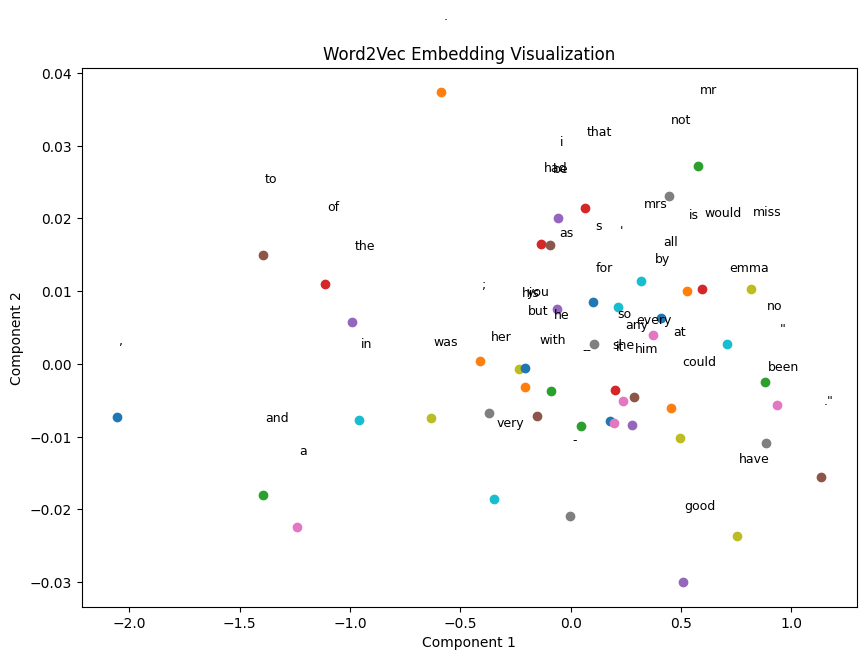

In [15]:
words = list(w2v_model.wv.index_to_key[:50])
vectors = [w2v_model.wv[word] for word in words]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(10,7))

for i, word in enumerate(words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word, fontsize=9)

plt.title('Word2Vec Embedding Visualization')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()